# **GTA Housing Prices and Municipalities Socioeconomic Characteristics** #

Name: Jiya Marwah 

### 1. Project Questions ###


This project investigates how housing prices vary across different municipalities in the Greater Toronto Area (GTA), and whether municipal-level socioeconomic characteristics from the 2021 Census are associated with those prices.

The population of interest is residential properties listed for sale across eight GTA municipalities.

The three research questions are:

1. Which GTA municipalities have the highest average housing prices, and how much do they differ from one another?
2. How does average housing price change as the number of bedrooms increases?
3. Is there an association between a municipality's median household income and its average housing price? Does education level show a similar pattern?

The key variables are property price, municipality, number of bedrooms, median household income, unemployment rate, and share of the population with a bachelor's degree or higher.

### 2. Data Sources ###


#### Dataset 1 - GTA Property Listings
**Source:** Kaggle - *Toronto Properties* by Mangaljit Singh  
**URL:** https://www.kaggle.com/datasets/mangaljitsingh/torontoproperties  
**File:** `clean_combined_toronto_property_data.xlsx`

This dataset has one row per property listing in the GTA. The columns I used are `price` (in CAD), `region` (which city the property is in), `address`, `bedrooms`, and `bathrooms`. There are 7,324 listings total across 31 municipalities, but I filtered it down to just the 8 cities I downloaded census data for, leaving 4,136 listings.

#### Dataset 2 - Statistics Canada 2021 Census Profiles
**Source:** Statistics Canada - *Census Profile, 2021 Census of Population*  
**URL:** https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E  
**Files:** Eight CSV files, one per municipality (Brampton, Mississauga, Toronto, Markham, Vaughan, Oakville, Richmond Hill, Burlington)

I downloaded one census file per city at the Census Subdivision (municipality) level. I only extracted five indicators: `population (2021)`, `median household income (2020)`, `unemployment rate`, `share of population with a bachelor's degree or higher`, and `low income rate (LIM-AT)`.

##### Shared Attribute (Join Key)
Both datasets have **municipality name** as a common attribute, which is the join key. The `region` column in the properties dataset had to be cleaned and mapped to a standardized municipality name (e.g., both `Old Toronto, Toronto, ON` and `Scarborough, Toronto, ON` map to `Toronto`), which matches the municipality name extracted from the census file.

##### Preprocessing
- Properties were filtered to rows whose `region` maps to one of the 8 census municipalities.
- Rows with missing `price`, `bedrooms`, or `bathrooms` were dropped (none were found after filtering).
- Census CSVs use `latin1` encoding and the actual data doesn't start until row 3, so I had to skip the header rows and rename the columns manually.
- The `pct_bachelor` field in the census data is provided as a raw count and is converted to a percentage of total population.

#### Database Schema

**Table: `properties`**
| Column | Type | Description |
|---|---|---|
| id | INTEGER (PK) | Auto-incremented |
| price | INTEGER | Listing price in CAD |
| region | TEXT | Original region string from dataset |
| address | TEXT | Property address |
| bedrooms | INTEGER | Number of bedrooms |
| bathrooms | INTEGER | Number of bathrooms |
| municipality | TEXT (FK) | Standardized municipality name |

**Table: `census`**
| Column | Type | Description |
|---|---|---|
| municipality | TEXT (PK) | Municipality name |
| population | INTEGER | 2021 population |
| median_household_income | INTEGER | Median total household income in 2020 ($) |
| unemployment_rate | REAL | Unemployment rate (%) |
| pct_bachelor | REAL | % of population with bachelor's degree or higher |
| pct_low_income | REAL | % in low income based on LIM-AT |

### 3. Analysis

#### 3.1 Setup

In [1]:
import sys
sys.path.insert(0, '.')

from project import (
    load_properties,
    load_census,
    create_database,
    query_avg_price_by_municipality,
    query_price_with_census,
    query_avg_price_by_bedrooms,
    query_listings_by_municipality,
    plot_avg_price_by_municipality,
    plot_price_vs_income,
    plot_price_by_bedrooms,
)

import pandas as pd
pd.set_option('display.float_format', '{:,.0f}'.format)

#### 3.2 Load Data and Build Database

In [2]:
# Load and clean the two datasets
properties_df = load_properties('clean_combined_toronto_property_data.xlsx')
census_df = load_census('.')

print(f'Properties loaded: {len(properties_df):,} listings across {properties_df["municipality"].nunique()} municipalities')
print(f'Census loaded: {len(census_df)} municipalities')

Properties loaded: 4,136 listings across 8 municipalities
Census loaded: 8 municipalities


In [3]:
# Preview the properties dataset
properties_df[['price', 'region', 'municipality', 'bedrooms', 'bathrooms']].head(8)

,price,region,municipality,bedrooms,bathrooms
0,799000,"Burlington, ON",Burlington,2,2
1,599900,"Burlington, ON",Burlington,2,2
2,1499000,"Burlington, ON",Burlington,3,2
3,1899900,"Burlington, ON",Burlington,3,4
4,649900,"Burlington, ON",Burlington,1,1
5,1699900,"Burlington, ON",Burlington,5,4
6,749000,"Burlington, ON",Burlington,3,2
7,500000,"Burlington, ON",Burlington,1,1


In [4]:
# Preview the census dataset
census_df

,municipality,population,median_household_income,unemployment_rate,pct_bachelor,pct_low_income
0,Brampton,656480,111000,13,25,6
1,Mississauga,717961,102000,14,32,9
2,Toronto,2794356,84000,14,35,13
3,Markham,338503,104000,14,33,11
4,Vaughan,323103,124000,12,30,6
5,Oakville,213759,128000,12,39,9
6,Richmond Hill,202022,102000,13,38,12
7,Burlington,186948,110000,11,29,6


In [5]:
# Create the SQLite database and populate both tables
DB_PATH = 'gta_housing.db'
create_database(DB_PATH, properties_df, census_df)
print('Database created with tables: properties, census')

Database created with tables: properties, census


#### 3.3 Query 1 - Average Price and Listing Count by Municipality

This query uses `GROUP BY` and the aggregate functions `AVG` and `COUNT` to summarize the properties table by municipality.

In [6]:
avg_price_df = query_avg_price_by_municipality(DB_PATH)
avg_price_df

,municipality,avg_price,listing_count
0,Oakville,"2,490,236",428
1,Richmond Hill,"1,954,222",384
2,Vaughan,"1,815,538",478
3,Markham,"1,673,423",483
4,Burlington,"1,320,899",310
5,Brampton,"1,296,141",597
6,Mississauga,"1,188,830",582
7,Toronto,"1,107,308",874


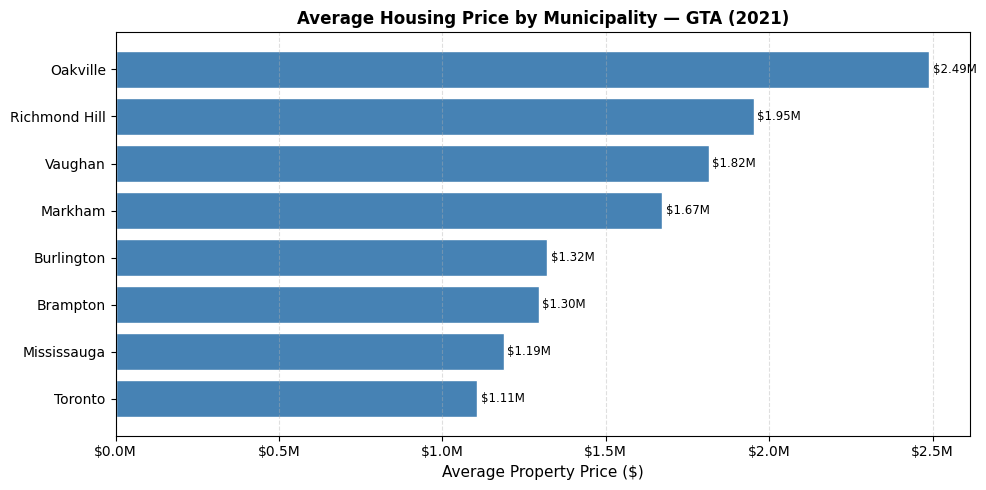

In [7]:
plot_avg_price_by_municipality(avg_price_df)

**Figure 1** shows average housing price by municipality sorted from lowest to highest. Oakville is the most expensive by a wide margin at around 2.5 million on average, more than double Toronto's average of approximately 1.1 million. Richmond Hill and Vaughan form a mid-high tier, while Mississauga and Toronto are the most affordable among the eight municipalities studied.

#### 3.4 Query 2 - Average Price by Number of Bedrooms

This query uses `GROUP BY bedrooms` and `AVG(price)` to examine how property size (by bedroom count) relates to price, filtered to listings with 1–6 bedrooms.

In [8]:
bedrooms_df = query_avg_price_by_bedrooms(DB_PATH)
bedrooms_df

,bedrooms,avg_price,listing_count
0,1,"682,568",490
1,2,"1,022,044",778
2,3,"1,331,470",1484
3,4,"2,056,307",1115
4,5,"3,626,142",197
5,6,"4,426,047",36


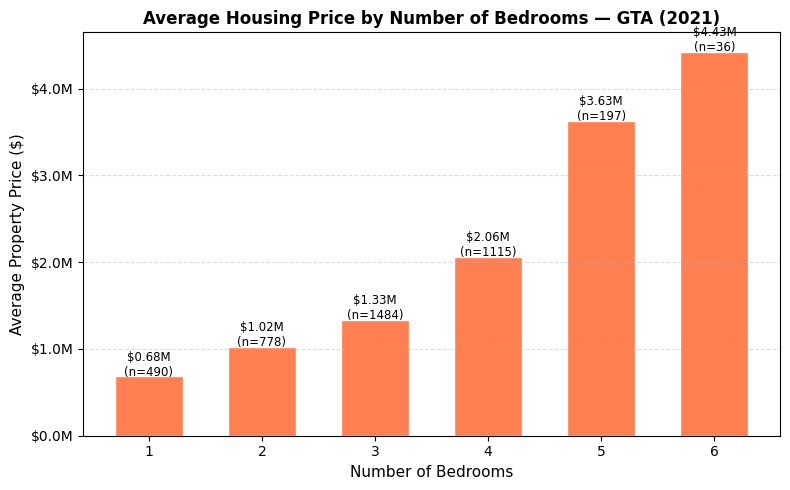

In [9]:
plot_price_by_bedrooms(bedrooms_df)

**Figure 2** shows a clear positive relationship between the number of bedrooms and average price. A 1-bedroom property averages around 683K, while a 5-bedroom property averages 3.6 million, more than five times as much. The increase is not perfectly linear. The jump from 4 to 5 bedrooms is way steeper than the earlier ones. Worth noting that the 5 and 6 bedroom averages are based on only 197 and 36 listings respectively, so those averages are less stable.

#### 3.5 Query 3 - JOIN: Housing Prices with Census Socioeconomic Data

This query joins the `properties` and `census` tables on `municipality`, combining average price and listing count with the five socioeconomic indicators from the census.

In [10]:
joined_df = query_price_with_census(DB_PATH)
joined_df

,municipality,avg_price,listing_count,median_household_income,unemployment_rate,pct_bachelor,pct_low_income
0,Oakville,"2,490,236",428,128000,12,39,9
1,Richmond Hill,"1,954,222",384,102000,13,38,12
2,Vaughan,"1,815,538",478,124000,12,30,6
3,Markham,"1,673,423",483,104000,14,33,11
4,Burlington,"1,320,899",310,110000,11,29,6
5,Brampton,"1,296,141",597,111000,13,25,6
6,Mississauga,"1,188,830",582,102000,14,32,9
7,Toronto,"1,107,308",874,84000,14,35,13


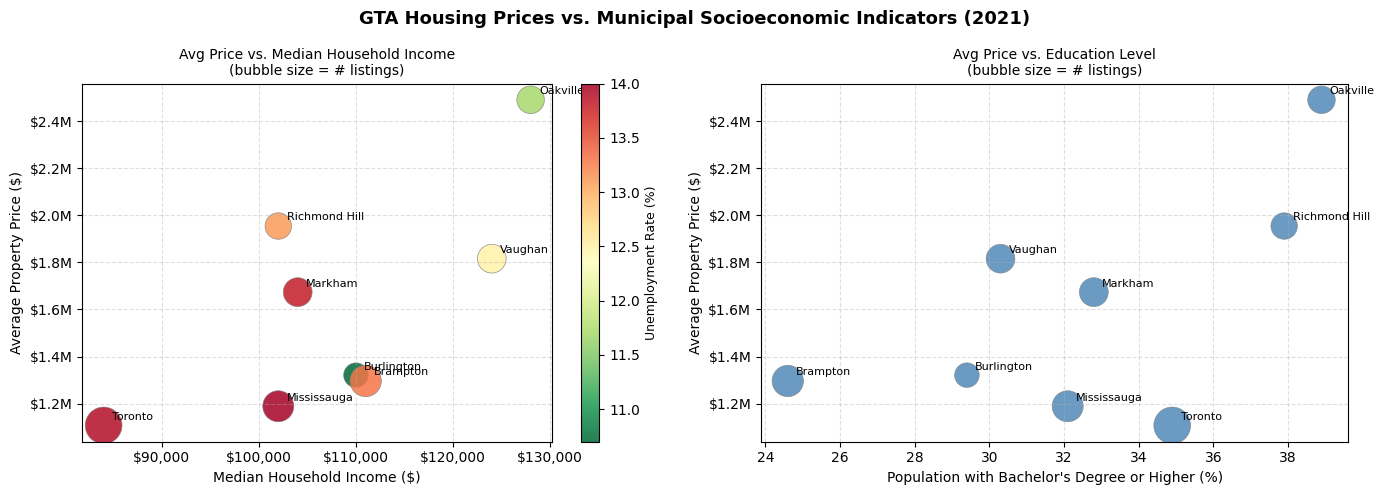

In [11]:
plot_price_vs_income(joined_df)

**Figure 3 (left)** shows average property price against median household income per municipality. Bubble size represents the number of listings, and colour represents unemployment rate (red = higher unemployment). There is a positive relationship: municipalities with higher household incomes (Oakville at 128K, Vaughan at 124K) tend to have higher average property prices. Toronto is an outlier: it has the lowest median household income (84K) and a high unemployment rate, but still has the most listings of any city in the dataset, reflecting its density and many different property types and neighbourhoods.

**Figure 3 (right)** looks at education levels showing the average price against the share of the population with a bachelor's degree or higher. Oakville, the most expensive municipality, also has the highest share of degree-holders (38.9%). However, the relationship is not perfectly consistent. Richmond Hill has a high education share (37.9%) but lower prices than Vaughan, which has a lower education share (30.3%). This suggests education level alone doesn't fully explain the price differences between cities.

#### 3.6 Query 4 - Parameterized: Listings for a Specific Municipality

This parameterized query retrieves all listings for a given municipality. It takes a municipality name as an argument and returns matching rows sorted by price. Below we demonstrate it for Oakville, the most expensive municipality in the dataset.

In [12]:
oakville_df = query_listings_by_municipality(DB_PATH, 'Oakville')
print(f'Total Oakville listings: {len(oakville_df)}')
print(f'Price range: ${oakville_df["price"].min():,} – ${oakville_df["price"].max():,}')
oakville_df.head(10)

Total Oakville listings: 428
Price range: $539,990 – $21,888,000


,price,region,address,bedrooms,bathrooms
0,21888000,"Oakville, ON","2064 LAKESHORE RD, Oakville, Ontario",5,8
1,21888000,"Oakville, ON","2064 LAKESHORE Road E, Oakville, Ontario",5,8
2,20880000,"Oakville, ON","21 ENNISCLARE DR E, Oakville, Ontario",4,7
3,18980000,"Oakville, ON","1092 ARGYLE DR, Oakville, Ontario",5,9
4,18980000,"Oakville, ON","1092 ARGYLE Drive, Oakville, Ontario",5,9
5,9988000,"Oakville, ON","1084 ARGYLE DR, Oakville, Ontario",3,3
6,9988000,"Oakville, ON","1084 ARGYLE Drive, Oakville, Ontario",3,3
7,9400000,"Oakville, ON","1225 LAWRENCE CRES, Oakville, Ontario",4,8
8,9400000,"Oakville, ON","1225 LAWRENCE Crescent, Oakville, Ontario",4,8
9,8200000,"Oakville, ON","259 BURGUNDY DR, Oakville, Ontario",4,6


In [13]:
# Demonstrate with a different municipality
toronto_df = query_listings_by_municipality(DB_PATH, 'Toronto')
print(f'Total Toronto listings: {len(toronto_df)}')
print(f'Price range: ${toronto_df["price"].min():,} – ${toronto_df["price"].max():,}')
toronto_df.head(10)

Total Toronto listings: 874
Price range: $399,000 – $8,800,000


,price,region,address,bedrooms,bathrooms
0,8800000,"Scarborough, Toronto, ON","2220 WARDEN AVE, Toronto, Ontario",3,2
1,7703888,"Old Toronto, Toronto, ON","#6202 -1 BLOOR ST W, Toronto, Ontario",2,3
2,7280000,"Old Toronto, Toronto, ON","109 SCOLLARD ST, Toronto, Ontario",3,5
3,6750000,"Old Toronto, Toronto, ON","13 HILLHOLM RD, Toronto, Ontario",5,5
4,5700000,"Old Toronto, Toronto, ON","#2402 -10 BELLAIR ST, Toronto, Ontario",2,3
5,4998000,"Old Toronto, Toronto, ON","#1002W -480 QUEENS QUAY W, Toronto, Ontario",3,4
6,4880000,"Old Toronto, Toronto, ON","#100 -113 DUPONT ST, Toronto, Ontario",2,4
7,4349000,"Old Toronto, Toronto, ON","71 CHATSWORTH DR, Toronto, Ontario",4,4
8,4295000,"Old Toronto, Toronto, ON","U 3 78 LOWTHER AVE, Toronto, Ontario",3,3
9,4241888,"Old Toronto, Toronto, ON","#5503 -1 BLOOR ST W, Toronto, Ontario",3,2


### 4. Results and Interpretation


**Question 1 - Which GTA municipalities have the highest average housing prices?**

Oakville has by far the highest average property price at approximately 2.49 million, followed by Richmond Hill (1.95 million) and Vaughan (1.82 million). Toronto and Mississauga are the most affordable in this group, averaging around 1.1 million and 1.2 million respectively. The range across municipalities is substantial as Oakville's average is more than twice Toronto's, suggesting that location within the GTA is a major determinant of price.

**Question 2 - How does price change with number of bedrooms?**

There is a strong positive relationship between bedroom count and average price across the dataset. Each additional bedroom adds a significant amount - going from 3 to 4 bedrooms adds around 725K on average, and from 4 to 5 adds another 1.57 million. This is consistent with the idea that larger homes tend to be detached houses on bigger lots which are priced much higher in the market.

**Question 3 - Is there an association between socioeconomic indicators and housing prices?**

The joined data shows a general positive association between median household income and average property price. Municipalities with higher household incomes (Oakville, Vaughan) tend to have higher average prices, while lower-income municipalities (Toronto, Mississauga) have lower average prices. The education relationship is less consistent - Oakville and Richmond Hill have the highest degree-holder shares and high prices, but Brampton has a much lower share of degree holders than Mississauga and their average prices are still very similar (1.30M vs 1.19M). This suggests that income and broader socioeconomic factors matter more than education level alone in determining housing prices at the municipal level.

### 5. Conclusions

This project examined GTA housing prices across eight municipalities using property listing data and 2021 Census socioeconomic indicators.

**The key findings are:**
- Municipality of location is the strongest price driver in this dataset. Oakville listings average 2.49 million compared to 1.1 million in Toronto showing a gap of over 1.3 million
- Bedroom count has a strong and consistent positive relationship with price, with average prices roughly quintupling from 1-bedroom to 5-bedroom properties.
- Median household income shows a positive association with average housing price at the municipal level, broadly consistent with the idea that wealthier communities have more expensive housing markets. The relationship with education level exists but is less reliable.

**Limitations:**
- The property dataset represents listings, not actual sale prices and listed prices may not reflect what homes were finally sold for.
- Some municipalities had duplicate listings for the same property (e.g. Oakville's top-priced entries appear twice with slightly different addresses) but I left them in since I had no reliable way to identify duplicates without a unique property ID. 
- The census data is from 2021 and uses 2020 income figures, while the listing data has no clear date stamp so there is a potential mismatch here which may affect the income-price comparisons.
- 8 municipalities is a considerably small sample for drawing conclusions about socioeconomic patterns. Trends visible in the scatter plots are suggestive but not conclusive.
- Important price drivers such as property size in square feet, lot size, property type (condo vs. detached), and proximity to transit are not available in this dataset.